# Кейс "Дизайн А/Б - эксперимента по увеличению конверсии в заявку на подключение тарифов (телеком)"

Продуктовый менеджер выступил с продуктовой идеей: изменение баннера формы подачи заявки на сайте на подключение тарифов (интернет, домашнее ТВ, мобильные пакеты) улучшит пользовательский опыт и повысит вероятность оставления заявки на подключение

Продуктовая проблема

Идея исходила из предположения, что существующая форма крайне неудобна, предполагает:

- сначала выбрать тариф, попасть на страницу оставления заявки
- на этой странице заполнить 3 поля: ФИО, адрес, мобильный телефон
- нажать на галочку "отказаться от рассылки"

Для реализации расчетов и дизайна эксперимента я буду изпользовать датасет "df_realistic" - это приближенная к реальным данным симуляция. Реальные данные компании использовать я не могу.

In [554]:
Данный проект также доступен на github


In [566]:
# Импорт данных

import pandas as pd
import numpy as np
dataset = pd.read_csv("df_realistic.csv", index_col=0)
dataset['date_time'] = pd.to_datetime(dataset['date_time'])
dataset.head(3)

,visitor_id,session_id,date_time,device_type,traffic_source,utm_campaign,region,landing_page,form_variant,is_applied
0,v_0025071,s_33872460922,2025-03-01 00:02:44,mobile,paid_search,msk_internet_brand,Moscow,/packages,control,0
1,v_0021622,s_23144853771,2025-03-01 00:03:20,mobile,direct,NaN,Moscow,/internet,control,0
2,v_0041293,s_13207490166,2025-03-01 00:14:15,mobile,direct,NaN,Moscow,/mobile,control,0


## Пред-анализ

На первом этапе я:
* <b>Проверил, действительно ли существует такая проблема?</b>

Как проверял: разложил воронку CJ на этапе "выбор тарифа -> заполнение заявки -> оставление заявки". Убедился, что всего 15.8% перешедших на страницу оставления заявки, реально ее оставляют:

In [321]:
cr_real = dataset['is_applied'].mean()
print (f'конверсия = {cr_real:.3f}')

конверсия = 0.158


* <b>Сравнил ситуацию с другими аналогичными лендингами</b> (такие же сайты в сопоставимых регионах - Санкт-Петербург, Казань, Нижний Новгород). Конверсия в оставление заявки там выше - на уровне 18-20%.
* <b>Сам прошел пользовательский путь на этих сайтах</b>, выписал, что у них работает лучше (лучше как и сама форма заявки, так и некоторые фичи, например - автозаполнение полей ввода)
* <b>Формализовал параметры воронки через цифры:</b> (здесь приведены приближенные к реальности цифры)
  * Трафик предыдущей страницы = 180к в месяц
  * Трафик страницы с оставлением заявки = 71к в месяц (39%)

In [324]:
trafic_apply_page = dataset.shape[0]
print(f'трафик страницы за март 2025: {trafic_apply_page}')

трафик страницы за март 2025: 71023


In [326]:
applied = dataset['is_applied'].sum()

  * Оставляют заявку = 11216 (15,8%)

In [329]:
converted = applied/trafic_apply_page
print (f'конверсия = {converted:.3f}')

конверсия = 0.158


  * Число подключений тарифов через сайт = 5400 в месяц (48% от всех заявок)
  * ARPU = 1000 руб.

Так, выручка подключений через сайт ~5,4 млн руб. в месяц

Из тех юзеров, которые зашли на страницу с выбором тарифа лишь 3% реально подключают тариф

Из тех юзеров, кто заходил на страницу оставления заявки, лишь 7% реально подключили тариф

In [332]:
arpu = 1000

In [334]:
connection_cr = 0.48

In [532]:
connection_revenue = 5400000

### Сформулировал продуктовую гипотезу:
<i> Если мы сократим количество полей, которые надо заполнить, добавим автозаполнение и изменим кнопку с "перезвоните мне" на "подключить тариф", конверсия в заявку на подключение тарифа вырастет как минимум до уровня других аналогичных лендингов (до 18%). </i> Важно: данный uplift считаем как бизнес-цель, а не как MDE

### Выбор метрик
На этом этапе я:

* Четко сформулировал, какую проблему мы хотим решить и как это измерить? <i> <b> Хотим решить проблему низкой конверсии со страницы оставления заявки в оставление самой заявки, чтобы в итоге увеличить конверсию в подключение тарифов через сайт, увеличить выручку подключений через сайт

* Метрики:

  * <b>Primary: CR в отправку заявки.</b> Почему: она отражает целевое действие, которое по нашему мнению, приведет к желаемому улучшению. Только эта метрика исользуется для приемки теста.
  * <b>Key business: CR “заявка → подтверждённое подключение”. </b>Почему: она отражает бизнес-ценность решения (деньги). Также она показывает, эффенктивно ли доводят заявку до реализации уже на следующих этапах
  * <b>Вспомогательные:</b>
      * среднее время обработки лида (нагрузка колл-центра)
      * время, проведенное на странице заявки
      * доля посетителей, начавших и не закончивших заполнение заявки
  * <b>Защитная:</b>
      * ARPU (connections). Нам важно, чтобы эта метрика не просела с запуском АБ теста

### Порядок приемки теста
1. Тест останавливается при консистентном ухудшении целевой, вспомогательной или защитной метрики в течение как минимум 3 дней
2. Тест останавливается при наличии высокой уверенности в возможном баге, верифицированном QA или разработчиком
3. Тест принимается по основной и единственной метрике. Успехом считается ее статзначимое улучшение на фоне отсутствия ухудшения прокси и защитной метрики
4. Стандартный уровень альфа: для основной метрики - 0.05, для второстепенных и защитных - 0.01
5. Для основной метрики тестируется улучшающая односторонняя гипотеза, для второстепенных метрик - двусторонняя гипотеза
6. Для защитной метрики тестируется ухудшающая односторонняя гипотеза
7. Любые изменения метрики, ниже уровня MDE при заданном уровне трафика, считаются случайными и не могут быть использованы для принятия решения по результатам теста

### Правила перезапусков
1. В случае невалидности предыдущего запуска теста, а также проведенной работе по устранению багов.
2. При неудачном проведении теста, после проведенной работы над ошибками, как в технической, продуктовой, или же UI/UX-частях.
3. Запрещается проводить перезапуск теста без видимых оснований или без проведенной работы над исправлением работоспособности
функционала. В таком случае перезапуск расценивается как попытка получить более благоприятный исход теста в силу случайности поведения
метрик.

### В каких случаях тест отвергается
1. Ухудшение целевой метрики в тритмент подмножестве пользователей.
2. Ухудшение хотя бы одной второстепенной метрики в тритмент подмножестве пользователей.
3. Ухудшение хотя бы одной guard метрики в тритмент подмножестве пользователей.

# Дизайн эксперимента

### Оценка реальной значимости эффектов от изменений

Убедился, что внедрение этих изменений будет экономически оправдано. В конкретном кейсе это означало, что условные затраты на изменение формы окупятся за счет потенциальной дополнительной выручки от подключений. 
* Если конверсия в подключение увеличится на 3 п.п. к текущим значениям (как и в других регионах), то при прочих равных это приведет к росту выручки от подклоючений на 162к руб. в месяц:

In [408]:
# Расчет эффекта в деньгах
converted_uplift_3pp = np.ceil(dataset['is_applied'].sum()*1.03) #/trafic_apply_page
connection_revenue = applied * connection_cr * arpu
connection_revenue_new = converted_uplift_3pp * connection_cr * arpu
connection_revenue_uplift = connection_revenue_new - connection_revenue
connection_revenue_uplift_percent = connection_revenue_uplift / connection_revenue
print (f'revenue uplift = {connection_revenue_uplift:.3f}')
print (f'connection_revenue_uplift_percent = {connection_revenue_uplift_percent:.3f}')

revenue uplift = 161760.000
connection_revenue_uplift_percent = 0.030


### Определение аудитории

Лендинг, на котором планируются изменения, открывается только при подлючении из Москвы и МО. На него не получится зайти из другого региона без технических вмешательств. Страница с оставлением заявки открывается только для неавторизованных пользователей, поскольку если пользователь авторизован (зарегистрирован), то заявка от него заполняется автоматически и он минует этот шаг при оформлении тарифов. Соответственно, потенциальная аудитория:
* неавторизованные пользователи
* со всех устройств

### Определение параметров ошибок 1го и 2го рода

In [347]:
#H0 -> Конверсия в заявку на подключение тарифа в treatment группе не будет отличаться от контрольной
#H1 -> Конверсия в заявку на подключение тарифа в treatment группе будет выше, чем в контрольной
alpha = 0.05
beta = 0.2

### Определение размера групп

Сначала оценим, что будет, если использовать на АБ тест весь трафик страницы оставления заявки на подключение тарифа (70к уникальных пользователей в месяц). При этом нужно учитывать, что реальный эффект желательно должен быть выше, чем MDE, тк в противном случае есть риск не засечь статзначимые результаты, даже если они будут (ошибка 2го рода)

<i> Ответим на вопрос: хватит ли нам этого трафика чтобы засечь улучшение конверсии на 1 пп?

In [412]:
from scipy.stats import norm

# Зафиксируем параметры симуляции
p1 = cr_real           # реальная конверсия на ретро-данных. Или, в терминах статистики, вероятность совершения целевого действия
delta = 0.01           # # минимальный абсолютный эффект, который хотим уметь детектировать
p2 = cr_real + delta   # целевая конверсия

var1 = p1*(1-p1)       # конверсия подчиняется биномиальному распределению
var2 = p2*(1-p2)

def sample_size_proportion_one_sided(var1, var2, delta, alpha=0.05, power=0.8):
    z_alpha = norm.ppf(1 - alpha)
    z_beta = norm.ppf(power)
    var_sum = (var1+var2)
    size = ((z_alpha + z_beta)**2 * var_sum) / (delta**2)
    
    return int(np.ceil(size))

n = sample_size_proportion_one_sided(var1, var2, delta)
print(f'размер группы = {n}')

размер группы = 16861


Чтобы засечь увеличение конверсии на 1 пп, нужно 16861 наблюдения в каждую группу, или, с учетом запаса, 34к наблюдений в сумме. Нашего трафика более чем достаточно.

Теперь ответим на вопрос продакта: "Сможем ли мы провести АБ-тест за 2 недели?, и при этом засечь эффект +3 п.п.?". Для этого выразим из формулы выше, какой MDE мы сможем получить, если тест будет длиться 2 недели

In [415]:
two_weeks_data = dataset[
        (dataset['date_time'] >= '2025-03-10') &
        (dataset['date_time'] < '2025-03-24')
]
two_weeks_data_size = two_weeks_data.shape[0]    # выбрал значения в 14-дневном интервале с понедельника по воскресенье, 
                                                 # тк предполагаем запускать тест в таком же диапазоне
              # не брал период 1-10 марта, т.к. там праздничный период, т.е. сезонность и отличная от обычных условий активность
two_weeks_data_size

32325

За 2 недели располагаем 32325 наблюдений, или по 16 тысяч в каждую группу

### Оценка MDE

In [424]:
def get_mde(p1, total_sample_size, alpha, beta):
    z_alpha = norm.ppf(1 - alpha)      # one-sided
    z_beta = norm.ppf(1 - beta)        # = norm.ppf(power)

    n_per_group = total_sample_size / 2
    var_sum = 2 * p1 * (1 - p1)

    mde = (z_alpha + z_beta) * np.sqrt(var_sum / n_per_group)
    return mde

mde = get_mde(converted, two_weeks_data_size, alpha, beta)
print(mde)         # в долях
print(mde + p1)   # в п.п.
print(p1)

0.010086507088263388
0.16800718067287682
0.15792067358461342


Получается, что за 2 недели мы в состоянии детектировать эффект в 1 п.п. конверсии. Нас это более, чем устраивает, поэтому продакт соглашается с установкой длительности теста в 2 недели.

## Тестирование дизайна

### Оценка вероятностей ошибок

In [428]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_pvalue_ecdf(pvalues, title=None):
    """Функция для воспроизведения графика кумулятивной 
    функции распределения p-value. Должна быть монотонно возрастающей
    для АА-тестов без эффекта и выпуклой для АБ-тестов"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    if title:
        plt.suptitle(title)

    sns.histplot(pvalues, ax=ax1, bins=20, stat='density')
    ax1.plot([0,1],[1,1], 'k--')
    ax1.set(xlabel='p-value', ylabel='Density')

    sns.ecdfplot(pvalues, ax=ax2)
    ax2.plot([0,1],[0,1], 'k--')
    ax2.set(xlabel='p-value', ylabel='Probability')
    ax2.grid()

На ретро-данных тракже проверю, способен ли тест контролировать уровни ошибок I и II рода. Для этого:
* сначала запущу 1000 решафл-тестов на визиторах предэксперементального периода, не добавляя никакого эффекта, чтобы проконтроллировать уровень ошибки I рода

In [431]:
from statsmodels.stats.proportion import proportions_ztest
users = two_weeks_data['visitor_id'].unique()
p_values = []

for i in range(1000):
    users_shuffled = users.copy()
    np.random.shuffle(users_shuffled)

    group_a = users_shuffled[:len(users_shuffled)//2]
    group_b = users_shuffled[len(users_shuffled)//2:]

    data_a = two_weeks_data[two_weeks_data['visitor_id'].isin(group_a)]
    data_b = two_weeks_data[two_weeks_data['visitor_id'].isin(group_b)]

    count = [data_a['is_applied'].sum(), data_b['is_applied'].sum()]
    nobs = [data_a['visitor_id'].nunique(), data_b['visitor_id'].nunique()]

    stat, p_value = proportions_ztest(count, nobs, alternative='smaller')
    p_values.append(p_value)
    
type_1_error_rate = len([x for x in p_values if x <= 0.05]) / len(p_values)
print(f'Нулевая гипотеза ошибочно отвергнута в {type_1_error_rate*100}%')

Нулевая гипотеза ошибочно отвергнута в 5.0%


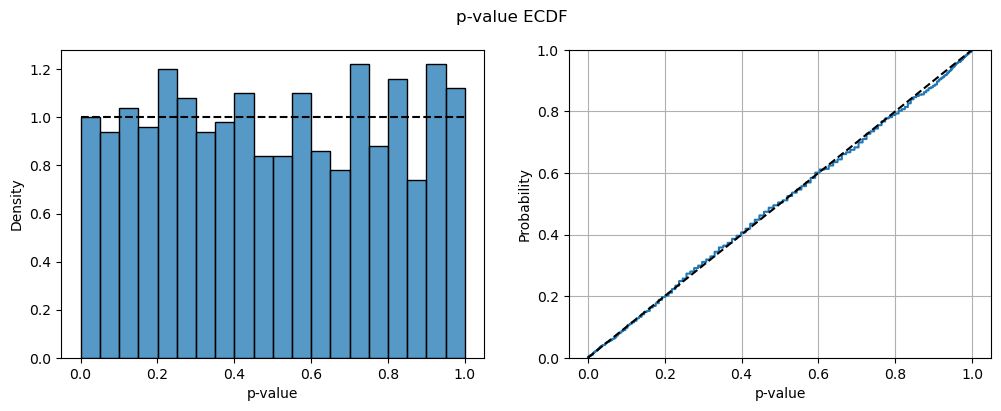

In [433]:
plot_pvalue_ecdf(p_values, 'p-value ECDF')

* затем запущу 1000 аналогичных тестов, прибавив эффект во вторую группу, чтобы проконтроллировать уровень ошибки II рода

In [436]:
p_values2 = []
p1 = two_weeks_data['is_applied'].mean()
mde = mde
p2 = p1 + mde

for i in range(1000):

    users_shuffled = users.copy()
    np.random.shuffle(users_shuffled)

    group_a = users_shuffled[:len(users_shuffled)//2]
    group_b = users_shuffled[len(users_shuffled)//2:]

    data_a = two_weeks_data[two_weeks_data['visitor_id'].isin(group_a)].copy()
    data_b = two_weeks_data[two_weeks_data['visitor_id'].isin(group_b)].copy()

    # синтетический эффект
    data_b['is_applied'] = np.random.binomial(1, p2, len(data_b))

    count = [data_a['is_applied'].sum(), data_b['is_applied'].sum()]
    nobs = [len(data_a), len(data_b)]

    stat, p_value = proportions_ztest(count, nobs, alternative='smaller')
    p_values2.append(p_value)
    type_2_error_rate = np.mean(np.array(p_values2) > 0.05)

print(f'Нулевая гипотеза ошибочно НЕ отвергнута в {type_2_error_rate*100}%')

Нулевая гипотеза ошибочно НЕ отвергнута в 15.6%


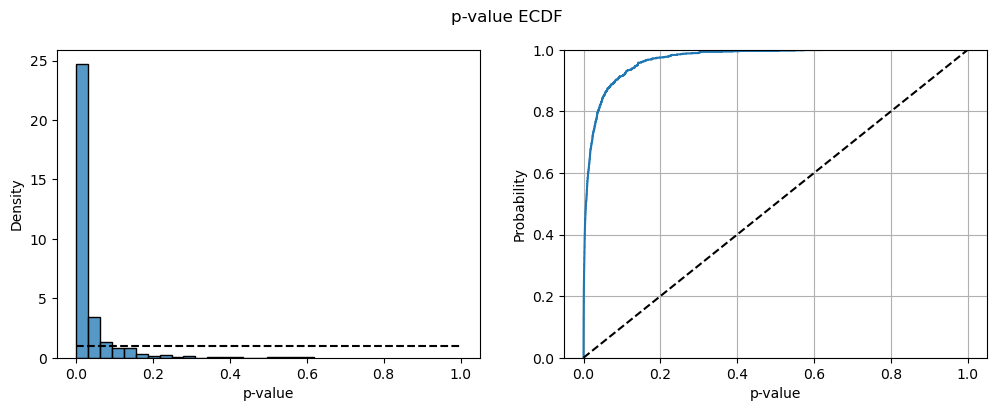

In [438]:
plot_pvalue_ecdf(p_values2, 'p-value ECDF')

Проведем синтетический АБ-тест (реализуем ту же логику со сдвигом ретроспективы)

In [537]:
synth_data = dataset[
        (dataset['date_time'] >= '2025-03-17') &
        (dataset['date_time'] < '2025-03-30')
]
synth_visitors = synth_data['visitor_id'].unique()
np.random.seed(23) # fix the random indexes
np.random.shuffle(synth_visitors)
synth_a_group = synth_visitors[:len(synth_visitors)//2]
synth_b_group = synth_visitors[len(synth_visitors)//2:]

a = synth_data[synth_data['visitor_id'].isin(synth_a_group)].copy()
b = synth_data[synth_data['visitor_id'].isin(synth_b_group)].copy()
b['is_applied'] = np.random.binomial(1, p2, len(b))

count = [a['is_applied'].sum(), b['is_applied'].sum()]
nobs = [len(a), len(b)]

stat, p_value = proportions_ztest(count, nobs, alternative='smaller')
print(f'z_statistics = {stat}, p_value = {p_value}')

z_statistics = -2.4075469366452484, p_value = 0.008030048816765762


### Boostrap - confidence interval
p-value - это точечная оценка. Для понимания уровня надежности оценки в дополнение строим доверительный интервал

In [506]:
values_group_a = a['is_applied']
values_group_b = b['is_applied']
est_a = values_group_a.mean()
est_b = values_group_b.mean()
# считаем разницу между 2 группами
diff = est_b - est_a

Процедура Bootstrap: многократно выбираем подвыборки с повторениями из начальной выборки, считаем разницу средних

In [541]:
bs_mean_estimates = []
n = 10000 # number of Bootstrap iterations
for i in range(n):
    bootstrap_a = np.random.choice(values_group_a, size = len(values_group_a), replace = True)
    bootstrap_b = np.random.choice(values_group_b, size = len(values_group_b), replace = True)
    est_bs_a = bootstrap_a.mean()
    est_bs_b = bootstrap_b.mean()
    estimation = est_bs_b - est_bs_a
    bs_mean_estimates.append(estimation)

Строим доверительный интервал

In [510]:
# normal CI
c = norm.ppf(1 - alpha/2)
se = np.std(bs_mean_estimates)
ci_norm_top = diff + c*se
ci_norm_bot = diff - c*se
print(f'[{ci_norm_bot}, {ci_norm_top}]')

[0.0018813756905425652, 0.01862389473929873]
